# Backtest: cartera real vs rebalanceo diario

Compara cinco estrategias desde la fecha de compra de los activos:

1. **Buy & Hold** — cartera tal como está, sin rebalancear
2. **Min Volatility** — pesos óptimos minimizando volatilidad (ignora sentimiento)
3. **Min Volatility + Sentimiento** — minimiza volatilidad escalando la diagonal de Σ con el score de noticias (`Σ̃[i,i] = Σ[i,i] * (1 − λ · sᵢ)`)
4. **Max Sharpe sin sentimiento** — pesos óptimos maximizando Sharpe (μ histórico puro)
5. **Max Sharpe con sentimiento** — ídem pero ajustando μ con el score de noticias del día anterior (`μ_adj[i] = μ[i] * (1 + λ · sᵢ)`)

In [19]:
import os
import sys

sys.path.insert(0, os.path.abspath("../src"))

import asyncio

import nest_asyncio

nest_asyncio.apply()

import warnings

warnings.filterwarnings("ignore")

from decimal import Decimal

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv("../.env")

from sqlalchemy import select
from sqlalchemy.ext.asyncio import async_sessionmaker, create_async_engine

from financial_assistant.config.settings import Settings
from financial_assistant.domain.models.market_data import OHLCV
from financial_assistant.domain.services.optimizer import (
    MaxSharpeStrategy,
    MinVolatilitySentimentStrategy,
    MinVolatilityStrategy,
    PortfolioOptimizer,
)
from financial_assistant.infrastructure.db.models import OHLCVRecordORM, PositionORM, SentimentHistoryORM

settings = Settings()
engine = create_async_engine(settings.effective_postgres_dsn)
Session = async_sessionmaker(engine, expire_on_commit=False)

print("Setup OK")

Setup OK


## 1. Carga de datos

In [20]:
USER_ID = 253489205
MIN_LOOKBACK_DAYS = 60  # días mínimos de historia para arrancar a optimizar


async def load_data():
    async with Session() as session:
        # Posiciones
        pos_result = await session.execute(
            select(PositionORM).join(PositionORM.portfolio).where(PositionORM.portfolio.has(user_id=USER_ID))
        )
        positions = pos_result.scalars().all()

        # OHLCV
        ohlcv_result = await session.execute(
            select(OHLCVRecordORM).order_by(OHLCVRecordORM.ticker, OHLCVRecordORM.date)
        )
        ohlcv_records = ohlcv_result.scalars().all()

        # Sentimiento histórico
        sent_result = await session.execute(
            select(SentimentHistoryORM).order_by(SentimentHistoryORM.ticker, SentimentHistoryORM.date)
        )
        sentiment_records = sent_result.scalars().all()

    return positions, ohlcv_records, sentiment_records


positions, ohlcv_records, sentiment_records = asyncio.run(load_data())

print(f"Posiciones: {len(positions)}")
print(f"Registros OHLCV: {len(ohlcv_records)}")
print(f"Registros sentimiento: {len(sentiment_records)}")

Posiciones: 4
Registros OHLCV: 1004
Registros sentimiento: 1301


In [21]:
# Posiciones como dict {ticker: (quantity, avg_cost_usd, purchase_date)}
pos_dict = {
    p.ticker: {"quantity": float(p.quantity), "avg_cost": float(p.avg_cost_usd), "purchase_date": p.purchase_date}
    for p in positions
}
tickers = list(pos_dict.keys())
purchase_date = min(v["purchase_date"] for v in pos_dict.values())

print(f"Tickers: {tickers}")
print(f"Fecha de compra: {purchase_date}")
print()
for ticker, p in pos_dict.items():
    print(f"  {ticker}: {p['quantity']} unidades @ ${p['avg_cost']:.2f}")

Tickers: ['AAPL', 'GOOGL', 'GLD', 'KO']
Fecha de compra: 2025-05-23

  AAPL: 10.0 unidades @ $194.68
  GOOGL: 10.0 unidades @ $167.89
  GLD: 20.0 unidades @ $423.75
  KO: 20.0 unidades @ $78.64


In [22]:
# DataFrame de precios de cierre (una columna por ticker)
ohlcv_df = pd.DataFrame(
    [{"date": r.date, "ticker": r.ticker, "close": float(r.close)} for r in ohlcv_records if r.ticker in tickers]
)
prices = ohlcv_df.pivot(index="date", columns="ticker", values="close").sort_index()
prices = prices[tickers]  # orden consistente
prices = prices[prices.index >= purchase_date]

# DataFrame de sentimiento (score diario por ticker, forward-fill días sin noticias)
if sentiment_records:
    sent_df = pd.DataFrame(
        [
            {"date": r.date, "ticker": r.ticker, "score": float(r.score)}
            for r in sentiment_records
            if r.ticker in tickers
        ]
    )
    sentiment = sent_df.pivot(index="date", columns="ticker", values="score")
    sentiment = sentiment.reindex(prices.index).ffill().fillna(0.0)
else:
    sentiment = pd.DataFrame(0.0, index=prices.index, columns=tickers)

print(f"Período: {prices.index[0]} → {prices.index[-1]} ({len(prices)} días de trading)")
prices.tail(3)

Período: 2025-05-23 → 2026-05-22 (251 días de trading)


ticker,AAPL,GOOGL,GLD,KO
date,,,,
2026-05-20,302.250000,388.910004,417.399994,81.550003
2026-05-21,304.989990,387.660004,416.989990,81.169998
2026-05-22,308.820007,382.970001,413.820007,81.480003


## 2. Estrategia 1 — Buy & Hold

In [23]:
quantities = pd.Series({t: pos_dict[t]["quantity"] for t in tickers})

# Valor de cartera en cada día = sum(qty_i * price_i(t))
portfolio_value_bh = (prices * quantities).sum(axis=1)

# Retorno normalizado (base 1 en purchase_date)
bh_returns = portfolio_value_bh / portfolio_value_bh.iloc[0]

print(f"Valor inicial:  ${portfolio_value_bh.iloc[0]:,.2f}")
print(f"Valor final:    ${portfolio_value_bh.iloc[-1]:,.2f}")
print(f"Retorno total:  {(bh_returns.iloc[-1] - 1) * 100:.2f}%")

Valor inicial:  $11,213.82
Valor final:    $16,823.90
Retorno total:  50.03%


## 3. Estrategias de rebalanceo

In [24]:
def build_ohlcv_list(prices_slice: pd.DataFrame) -> dict[str, list[OHLCV]]:
    """Convierte un slice del DataFrame de precios al formato que espera PortfolioOptimizer."""
    result = {}
    for ticker in prices_slice.columns:
        records = []
        for dt, price in prices_slice[ticker].items():
            if not np.isnan(price):
                records.append(
                    OHLCV(
                        ticker=ticker,
                        date=dt,
                        open=Decimal(str(round(price, 6))),
                        high=Decimal(str(round(price, 6))),
                        low=Decimal(str(round(price, 6))),
                        close=Decimal(str(round(price, 6))),
                        volume=1000000,
                    )
                )
        result[ticker] = records
    return result


def backtest_rebalance(
    prices: pd.DataFrame,
    sentiment: pd.DataFrame,
    strategy,
    use_sentiment: bool = False,
) -> pd.Series:
    """
    Simula rebalanceo diario con la estrategia indicada.

    Args:
        strategy: instancia de OptimizationStrategy. Cada estrategia decide en su
                  propio preprocess() cómo usar el sentiment_map (ajuste de μ, Σ, etc.)
        use_sentiment: si True, pasa el score del día anterior al optimizer.
                       La estrategia decide qué hacer con él.
    """
    optimizer = PortfolioOptimizer(risk_free_rate=0.05, sentiment_lambda=0.10)
    daily_returns = prices.pct_change().fillna(0.0)

    initial_value = float((prices.iloc[0] * quantities).sum())
    portfolio_value = initial_value
    values = [initial_value]
    dates = [prices.index[0]]

    current_weights = (prices.iloc[0] * quantities) / initial_value
    current_weights = current_weights.to_dict()

    for i in range(1, len(prices)):
        today = prices.index[i]
        ret = daily_returns.iloc[i]

        port_ret = sum(current_weights.get(t, 0.0) * ret[t] for t in tickers)
        portfolio_value *= 1 + port_ret
        values.append(portfolio_value)
        dates.append(today)

        if i >= MIN_LOOKBACK_DAYS:
            history = prices.iloc[:i]
            ohlcv = build_ohlcv_list(history)

            sent_map = None
            if use_sentiment:
                prev_sent = sentiment.iloc[i - 1]
                sent_map = {t: float(prev_sent[t]) for t in tickers if not np.isnan(prev_sent[t])}

            result = optimizer.optimize(ohlcv, sentiment_map=sent_map, strategy=strategy)
            if result is not None:
                current_weights = {t: result.weights.get(t, 0.0) for t in tickers}

    return pd.Series(values, index=dates)


print("Calculando rebalanceo — Min Volatility...")
value_min_vol = backtest_rebalance(prices, sentiment, MinVolatilityStrategy())
ret_min_vol = value_min_vol / value_min_vol.iloc[0]
print(f"  Retorno total: {(ret_min_vol.iloc[-1] - 1) * 100:.2f}%")

print("Calculando rebalanceo — Min Volatility + Sentimiento...")
value_min_vol_sent = backtest_rebalance(prices, sentiment, MinVolatilitySentimentStrategy(), use_sentiment=True)
ret_min_vol_sent = value_min_vol_sent / value_min_vol_sent.iloc[0]
print(f"  Retorno total: {(ret_min_vol_sent.iloc[-1] - 1) * 100:.2f}%")

print("Calculando rebalanceo — Max Sharpe sin sentimiento...")
value_max_sharpe = backtest_rebalance(prices, sentiment, MaxSharpeStrategy(), use_sentiment=False)
ret_max_sharpe = value_max_sharpe / value_max_sharpe.iloc[0]
print(f"  Retorno total: {(ret_max_sharpe.iloc[-1] - 1) * 100:.2f}%")

print("Calculando rebalanceo — Max Sharpe con sentimiento...")
value_max_sharpe_sent = backtest_rebalance(prices, sentiment, MaxSharpeStrategy(), use_sentiment=True)
ret_max_sharpe_sent = value_max_sharpe_sent / value_max_sharpe_sent.iloc[0]
print(f"  Retorno total: {(ret_max_sharpe_sent.iloc[-1] - 1) * 100:.2f}%")

Calculando rebalanceo — Min Volatility...
  Retorno total: 45.99%
Calculando rebalanceo — Min Volatility + Sentimiento...
  Retorno total: 46.61%
Calculando rebalanceo — Max Sharpe sin sentimiento...
  Retorno total: 67.48%
Calculando rebalanceo — Max Sharpe con sentimiento...
  Retorno total: 68.88%


## 4. Métricas comparativas

In [25]:
def compute_metrics(value_series: pd.Series, label: str) -> dict:
    daily_ret = value_series.pct_change().dropna()
    total_days = (value_series.index[-1] - value_series.index[0]).days
    years = total_days / 365.25

    total_return = (value_series.iloc[-1] / value_series.iloc[0]) - 1
    cagr = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0
    vol = daily_ret.std() * np.sqrt(252)
    sharpe = (daily_ret.mean() * 252 - 0.05) / vol if vol > 0 else 0

    cummax = value_series.cummax()
    drawdown = (value_series - cummax) / cummax
    max_dd = drawdown.min()

    return {
        "Estrategia": label,
        "Retorno total": f"{total_return * 100:.2f}%",
        "CAGR": f"{cagr * 100:.2f}%",
        "Volatilidad anual": f"{vol * 100:.2f}%",
        "Sharpe ratio": f"{sharpe:.3f}",
        "Max drawdown": f"{max_dd * 100:.2f}%",
    }


metrics = pd.DataFrame(
    [
        compute_metrics(portfolio_value_bh, "Buy & Hold"),
        compute_metrics(value_min_vol, "Min Volatility"),
        compute_metrics(value_min_vol_sent, "Min Volatility (Σ-sentimiento)"),
        compute_metrics(value_max_sharpe, "Max Sharpe (sin sentimiento)"),
        compute_metrics(value_max_sharpe_sent, "Max Sharpe (con sentimiento)"),
    ]
).set_index("Estrategia")

metrics

,Retorno total,CAGR,Volatilidad anual,Sharpe ratio,Max drawdown
Estrategia,,,,,
Buy & Hold,50.03%,50.24%,17.42%,2.149,-14.38%
Min Volatility,45.99%,46.18%,11.79%,2.871,-9.18%
Min Volatility (Σ-sentimiento),46.61%,46.80%,11.80%,2.905,-9.04%
Max Sharpe (sin sentimiento),67.48%,67.77%,19.35%,2.527,-17.04%
Max Sharpe (con sentimiento),68.88%,69.18%,19.30%,2.575,-16.92%


## 5. Gráfico de rendimiento acumulado

In [ ]:
def plot_backtest(series_list, title, filename):
    """Gráfico de rendimiento acumulado + drawdown para un conjunto de series."""
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

    ax1 = axes[0]
    for ret, _, label, color in series_list:
        ax1.plot(ret.index, ret.values, label=label, color=color, linewidth=2)
    ax1.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax1.set_title(title, fontsize=14, fontweight="bold")
    ax1.set_ylabel("Valor relativo")
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    ax2 = axes[1]
    for _, value, label, color in series_list:
        dd = (value - value.cummax()) / value.cummax() * 100
        ax2.fill_between(dd.index, dd.values, 0, alpha=0.2, color=color)
        ax2.plot(dd.index, dd.values, color=color, linewidth=1, label=label)
    ax2.set_title("Drawdown (%)", fontsize=11)
    ax2.set_ylabel("Drawdown %")
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Gráfico guardado como {filename}")


# Gráfico 1 — Max Sharpe con y sin sentimiento vs Buy & Hold
plot_backtest(
    [
        (bh_returns, portfolio_value_bh, "Buy & Hold", "steelblue"),
        (ret_max_sharpe, value_max_sharpe, "Max Sharpe (sin sentimiento)", "darkorange"),
        (ret_max_sharpe_sent, value_max_sharpe_sent, "Max Sharpe (con sentimiento)", "seagreen"),
    ],
    title="Max Sharpe — impacto del ajuste de sentimiento en μ (base = 1)",
    filename="portfolio_backtest_sharpe.png",
)

# Gráfico 2 — Min Volatility con y sin sentimiento vs Buy & Hold
plot_backtest(
    [
        (bh_returns, portfolio_value_bh, "Buy & Hold", "steelblue"),
        (ret_min_vol, value_min_vol, "Min Volatility", "mediumpurple"),
        (ret_min_vol_sent, value_min_vol_sent, "Min Volatility (Σ-sentimiento)", "orchid"),
    ],
    title="Min Volatility — impacto del escalado de Σ por sentimiento (base = 1)",
    filename="portfolio_backtest_minvol.png",
)

## 6. Contribución del sentimiento

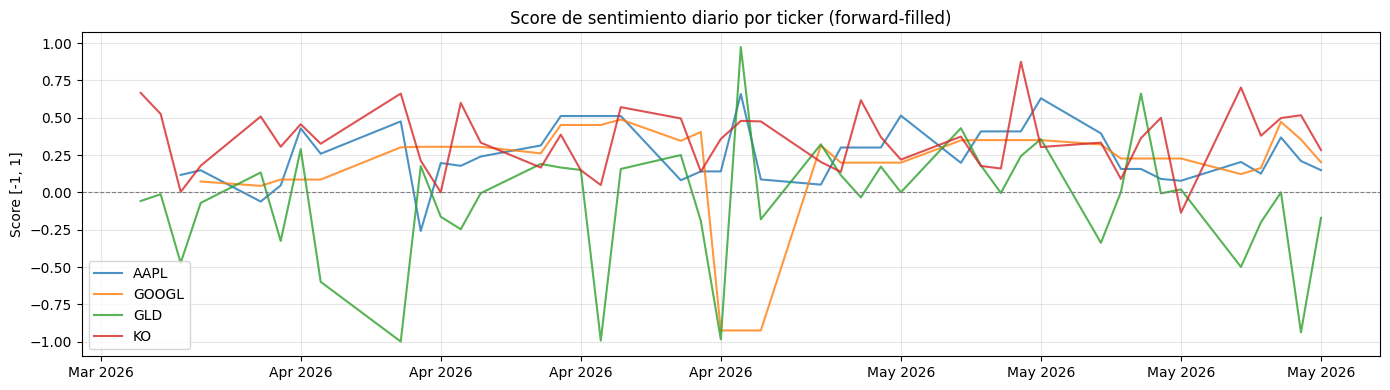

In [26]:
if sentiment_records:
    fig, ax = plt.subplots(figsize=(14, 4))
    for ticker in tickers:
        if ticker in sentiment.columns:
            s = sentiment[ticker].replace(0, np.nan).dropna()
            if not s.empty:
                ax.plot(s.index, s.values, label=ticker, linewidth=1.5, alpha=0.8)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title("Score de sentimiento diario por ticker (forward-filled)", fontsize=12)
    ax.set_ylabel("Score [-1, 1]")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de sentimiento en la base de datos.")
    print("Pedile al bot noticias de tus tickers para poblar la tabla sentiment_history.")